In [27]:
import pandas as pd
import seaborn as sns

8097
Index(['species', 'superkingdom', 'phylum', 'class', 'order', 'family'], dtype='str')
11103
8098


C:\Users\vmilesi\AppData\Local\Temp\ipykernel_2416\4116651147.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_archaea, x='OGT', y='class', palette='tab10')


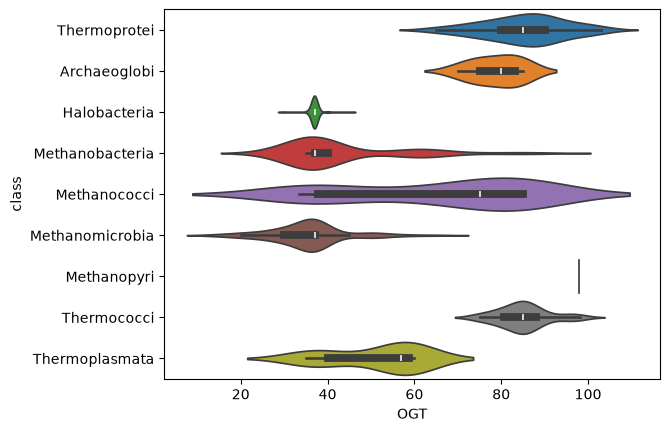

In [34]:
sp_tax = r'Q:\Documents\Projets\Methanogens\DavidBSauer_Github\OGT_prediction\data\calculations\feature_calculation\species_taxonomic.txt'
sp_OGT = r'Q:\Documents\Projets\Methanogens\DavidBSauer_Github\thermostability\all_merged_12_10_2012.txt'

df_tax = pd.read_csv(sp_tax, sep='\t', header=0)
print(len(df_tax))
print(df_tax.columns)

df_OGT = pd.read_csv(sp_OGT, sep='\t', header=0, names=['species_ogt', 'OGT', 'source'])
print(len(df_OGT))

df_merged = pd.merge(df_tax, df_OGT, left_on='species', right_on='species_ogt', how='inner')
df_merged['species_ogt'] = df_merged['species_ogt'].str.replace('_', ' ', regex=False)
df_merged['species_ogt'] = df_merged['species_ogt'].str.capitalize()
print(len(df_merged))

df_archaea = df_merged[df_merged['superkingdom'] == 'Archaea'].reset_index(drop=True)
df_archaea = df_archaea.sort_values(by=['superkingdom', 'phylum', 'class', 'order', 'family', 'species'])
sns.violinplot(data=df_archaea, x='OGT', y='class', palette='tab10')

df_archaea.to_excel(r'Q:\Documents\Projets\Methanogens\Archaea_OGT.xlsx', index=False)